# **Load library and data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [ ]:
# Load the dataset
pilgrim = pd.read_csv("pilgrimBdata.csv")

In [ ]:
pilgrim.head()

,ID,Profit99,Online99,Age99,Inc99,Tenure99,District99,Profit00,Online00,Billpay99,Billpay00
0,1,21,0,NaN,NaN,6.33,1200,NaN,NaN,0,NaN
1,2,-6,0,6.0,3.0,29.50,1200,-32.0,0.0,0,0.0
2,3,-49,1,5.0,5.0,26.41,1100,-22.0,1.0,0,0.0
3,4,-4,0,NaN,NaN,2.25,1200,NaN,NaN,0,NaN
4,5,-61,0,2.0,9.0,9.91,1200,-4.0,0.0,0,0.0


In [ ]:
pilgrim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31634 entries, 0 to 31633
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          31634 non-null  int64  
 1   Profit99    31634 non-null  int64  
 2   Online99    31634 non-null  int64  
 3   Age99       23345 non-null  float64
 4   Inc99       23373 non-null  float64
 5   Tenure99    31634 non-null  float64
 6   District99  31634 non-null  int64  
 7   Profit00    26396 non-null  float64
 8   Online00    26415 non-null  float64
 9   Billpay99   31634 non-null  int64  
 10  Billpay00   26415 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 2.7 MB


# 1. Recreate the "Profitability Skew" (Whale Plot)

In [ ]:
# Sort the data by Profit99 in descending order
pilgrim = pilgrim.sort_values(by="Profit99", ascending=False)

# Cumulative profit percentage
pilgrim['profitpt'] = pilgrim['Profit99'].cumsum() / pilgrim['Profit99'].sum()

# Cumulative customer percentage
pilgrim['customerpt'] = np.arange(1, len(pilgrim) + 1) / len(pilgrim)

pilgrim.head()

,ID,Profit99,Online99,Age99,Inc99,Tenure99,District99,Profit00,Online00,Billpay99,Billpay00,profitpt,customerpt
6459,6460,2071,0,5.0,7.0,23.75,1200,1909.0,0.0,0,0.0,0.000587,0.000032
1261,1262,2063,0,3.0,9.0,2.75,1200,331.0,0.0,0,0.0,0.001172,0.000063
30181,30182,2062,0,5.0,5.0,21.25,1200,1722.0,0.0,0,0.0,0.001757,0.000095
29875,29876,2062,0,4.0,7.0,1.25,1200,1714.0,0.0,0,0.0,0.002341,0.000126
24635,24636,2061,0,4.0,9.0,21.16,1200,3316.0,0.0,0,0.0,0.002925,0.000158


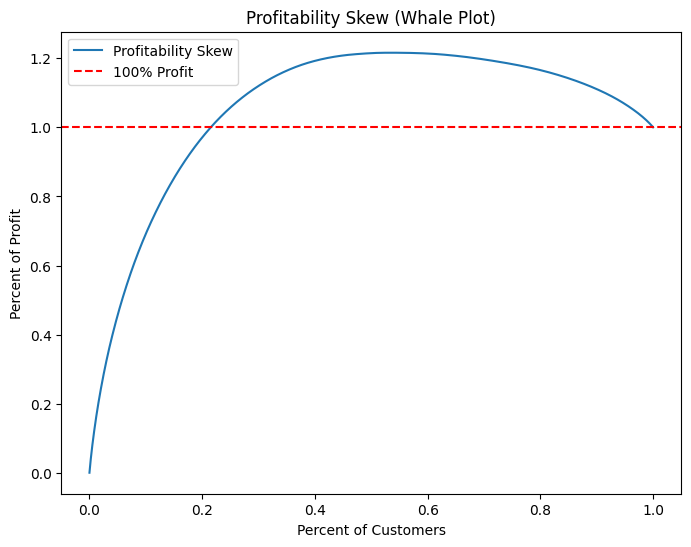

In [ ]:
# Plot the whale plot
plt.figure(figsize=(8, 6))
plt.plot(pilgrim['customerpt'], pilgrim['profitpt'], label='Profitability Skew')
plt.axhline(y=1, color='red', linestyle='--', label='100% Profit')
plt.xlabel("Percent of Customers")
plt.ylabel("Percent of Profit")
plt.title("Profitability Skew (Whale Plot)")
plt.legend()
plt.show()

In [ ]:
percent_customers = pilgrim.loc[pilgrim['profitpt'] >= 1, 'customerpt'].iloc[0]
print(f"Percentage of customers required for 100% profit: {percent_customers * 100:.2f}%")

Percentage of customers required for 100% profit: 21.53%


In [ ]:
# Filter for profitable customers only (Profit99 > 0)
profitable_customers = pilgrim[pilgrim['Profit99'] > 0]

# Calculate the maximum profit percentage and the percentage of customers needed
max_profit_percentage = profitable_customers['Profit99'].sum() / pilgrim['Profit99'].sum()
customers_for_max_profit = len(profitable_customers) / len(pilgrim)

# Print results
print(f"Percentage of total profit realized by targeting profitable customers: {max_profit_percentage * 100:.2f}%")
print(f"Percentage of customers needed to realize this maximum profit: {customers_for_max_profit * 100:.2f}%")


Percentage of total profit realized by targeting profitable customers: 121.58%
Percentage of customers needed to realize this maximum profit: 53.21%


# 3. Regression Analysis on Profit and Online Usage

In [ ]:
# Create age variable
age_mapping = {1: 10, 2: 20, 3: 30, 4: 40, 5: 50, 6: 60, 7: 70}
pilgrim['Age'] = pilgrim['Age99'].map(age_mapping)
pilgrim['AgeMiss'] = np.where(pilgrim['Age99'].isna(), 1, 0)
pilgrim['AgeMean'] = pilgrim['Age'].fillna(pilgrim['Age'].mean())



In [ ]:
# Create income variable
income_mapping = {1: 12500, 2: 17500, 3: 25000, 4: 35000, 5: 45000, 6: 62500,
                  7: 87500, 8: 112500, 9: 150000}
pilgrim['Inc'] = pilgrim['Inc99'].map(income_mapping)
pilgrim['IncMiss'] = np.where(pilgrim['Inc99'].isna(), 1, 0)
pilgrim['IncMean'] = pilgrim['Inc'].fillna(pilgrim['Inc'].mean())



## Model 1 : Profit99 ~ Online99

In [ ]:
mod_online = smf.ols("Profit99 ~ Online99", data=pilgrim).fit()
print(mod_online.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit99   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.572
Date:                Mon, 03 Mar 2025   Prob (F-statistic):              0.210
Time:                        00:25:57   Log-Likelihood:            -2.2232e+05
No. Observations:               31634   AIC:                         4.446e+05
Df Residuals:                   31632   BIC:                         4.447e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    110.7862      1.637     67.678      0.0

## Model 2 Age mean : Profit99 ~ Online99 + AgeMiss + AgeMean + Tenure99 + C(District99)

In [ ]:
# Model 2 Age mean: Profit99 ~ Online99 + AgeMiss + AgeMean + Tenure99 + District99
mod_2= smf.ols(
    "Profit99 ~ Online99 + AgeMiss + AgeMean + Tenure99 + C(District99)",
    data=pilgrim
).fit()
print(mod_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit99   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     261.6
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:29:29   Log-Likelihood:            -2.2155e+05
No. Observations:               31634   AIC:                         4.431e+05
Df Residuals:                   31627   BIC:                         4.432e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -25.42

## Model 3: Profit99 ~ Online99 + IncMiss + IncMean + Tenure99 + District99

In [ ]:
# Model 3 Income Mean: Profit99 ~ Online99 + IncMiss + IncMean + Tenure99 + District99
mod_3_mean = smf.ols(
    "Profit99 ~ Online99 + IncMiss + IncMean + Tenure99 + C(District99)",
    data=pilgrim
).fit()
print(mod_3_mean.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit99   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     335.2
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:29:51   Log-Likelihood:            -2.2134e+05
No. Observations:               31634   AIC:                         4.427e+05
Df Residuals:                   31627   BIC:                         4.428e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -18.36

## Model 4 : Profit99 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)

In [ ]:
# Model 4: Profit99 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + District99
mod_4 = smf.ols(
    "Profit99 ~ Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)",
    data=pilgrim
).fit()
print(mod_4.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit99   R-squared:                       0.066
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     279.2
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:30:04   Log-Likelihood:            -2.2124e+05
No. Observations:               31634   AIC:                         4.425e+05
Df Residuals:                   31625   BIC:                         4.426e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -80.29

# 5. Predict Profit00 using Profit99 and other variables

In [ ]:
mod_future_profit = smf.ols(
    "Profit00 ~ Profit99 + Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)",
    data=pilgrim
).fit()
print(mod_future_profit.summary())

                            OLS Regression Results                            
Dep. Variable:               Profit00   R-squared:                       0.362
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1661.
Date:                Mon, 03 Mar 2025   Prob (F-statistic):               0.00
Time:                        00:31:34   Log-Likelihood:            -1.8901e+05
No. Observations:               26396   AIC:                         3.780e+05
Df Residuals:                   26386   BIC:                         3.781e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 3.63

# 6. Predict retention (logistic regression)

In [ ]:
pilgrim['Retention'] = np.where(pilgrim['Profit00'].notna(), 1, 0)
mod_retention = smf.logit(
    "Retention ~ Profit99 + Online99 + AgeMiss + AgeMean + IncMiss + IncMean + Tenure99 + C(District99)",
    data=pilgrim
).fit()
print(mod_retention.summary())

Optimization terminated successfully.
         Current function value: 0.368315
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              Retention   No. Observations:                31634
Model:                          Logit   Df Residuals:                    31624
Method:                           MLE   Df Model:                            9
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.1794
Time:                        00:32:11   Log-Likelihood:                -11651.
converged:                       True   LL-Null:                       -14198.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.5951      0.088     18.098      0.000       1.422       1.

In [ ]:
# Add retention predictions
pilgrim['Retention_pred_prob'] = mod_retention.predict(pilgrim)
pilgrim['Retention_pred'] = np.where(pilgrim['Retention_pred_prob'] >= 0.5, 1, 0)

# Confusion matrix
cm = confusion_matrix(pilgrim['Retention'], pilgrim['Retention_pred'])
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  359  4879]
 [  263 26133]]
